# Imports

In [1]:
#running on google colab
on_google_colab = False

In [2]:
#google colab installs
if on_google_colab:
    !pip3 install pydicom

In [3]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import pydicom
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (None)/charset_normalizer (2.1.0) doesn't match a supported version!
  warnings.warn(


In [ ]:
#seed used for random
seed = 42
torch.manual_seed(seed)

In [5]:
#device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [6]:
#colab settings
if on_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/upenn_measurement_project/model_directory')

# Loading measurement data

In [ ]:
#read csv
measurement_file = "08242025.csv"

df = pd.read_csv(f"../data/measurements/{measurement_file}")

print(df.columns)

#drop unnecessary columns
df.drop(columns = ["Student Name", "Notes", "Date Completed", "Unnamed: 24", "Unnamed: 25", "Unnamed: 26", "Unnamed: 27"], inplace = True)

print(df.columns.values)

print(len(df.columns.values))

Index(['Student Name', 'ID', 'L Medial Cortical Thickness',
       'L Lateral Cortical Thickness ', 'L Shaft Width',
       'L Femoral Head Diameter', 'L Horizontal Offset', 'L Vertical Offset',
       'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       'R Medial Cortical Thickness', 'R Lateral Cortical Thickness ',
       'R Shaft Width', 'R Femoral Head Diameter', 'R Horizontal Offset',
       'R Vertical Offset', 'R Femoral Neck Width', 'R Hip Axis Length',
       'R Femoral Neck Axis Length', 'R Femoral Neck-Shaft  Angle', 'Notes',
       'Date Completed', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27'],
      dtype='object')
Index(['ID', 'L Medial Cortical Thickness', 'L Lateral Cortical Thickness ',
       'L Shaft Width', 'L Femoral Head Diameter', 'L Horizontal Offset',
       'L Vertical Offset', 'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Nec

In [8]:
#get rid of images with na (only temporary for convenience)
df = df.dropna()

# Pre-learned kernels for edge detection

In [9]:
def gaussian_kernel1d(kernel_size: int, sigma: float) -> torch.Tensor:
    """Creates a 1D Gaussian kernel."""
    half = kernel_size // 2
    x = torch.arange(-half, half + 1, dtype=torch.float32)
    kernel = torch.exp(-0.5 * (x / sigma) ** 2)
    kernel /= kernel.sum()
    return kernel

def gaussian_blur(img: torch.Tensor, sigma: float) -> torch.Tensor:
    """
    Applies 2D Gaussian blur to a 4D tensor [B, C, H, W] using separable convolution.
    """
    kernel_size = int(2 * round(3 * sigma) + 1)
    kernel1d = gaussian_kernel1d(kernel_size, sigma).to(img.device)

    kernel_x = kernel1d.view(1, 1, 1, -1)
    kernel_y = kernel1d.view(1, 1, -1, 1)

    # Apply horizontal then vertical blur
    blurred = F.conv2d(img, kernel_x, padding=(0, kernel_size // 2), groups=img.shape[1])
    blurred = F.conv2d(blurred, kernel_y, padding=(kernel_size // 2, 0), groups=img.shape[1])
    return blurred

def difference_of_gaussians(img: torch.Tensor, sigma1=1, sigma2=10) -> torch.Tensor:
    """
    Computes Difference of Gaussians on a 4D tensor [B, C, H, W].

    Args:
        img (torch.Tensor): Normalized image tensor in [0, 1], shape [B, C, H, W]
        sigma1 (float): Smaller sigma (less blur).
        sigma2 (float): Larger sigma (more blur).

    Returns:
        torch.Tensor: DoG result, shape [B, C, H, W], normalized to [0, 1].
    """
    g1 = gaussian_blur(img, sigma1)
    g2 = gaussian_blur(img, sigma2)
    dog = torch.abs(g1 - g2)
    dog = dog / (dog.amax(dim=(-2, -1), keepdim=True) + 1e-5)
    # dog = 1 - dog
    # dog = dog ** 1.5
    # dog = torch.where(dog > 0.95, dog, torch.zeros_like(dog))
    return dog

In [10]:
def sobel_edge_manual(img_tensor):
    device = img_tensor.device

    sobel_x = torch.tensor([[[-1., 0., 1.],
                             [-2., 0., 2.],
                             [-1., 0., 1.]]], dtype=torch.float32).to(device)

    sobel_y = torch.tensor([[[-1., -2., -1.],
                             [ 0.,  0.,  0.],
                             [ 1.,  2.,  1.]]], dtype=torch.float32).to(device)

    sobel_x = sobel_x.view(1, 1, 3, 3)
    sobel_y = sobel_y.view(1, 1, 3, 3)

    grad_x = F.conv2d(img_tensor, sobel_x, padding=1)
    grad_y = F.conv2d(img_tensor, sobel_y, padding=1)

    grad = torch.sqrt(grad_x ** 2 + grad_y ** 2)
    grad = grad / (grad.max() + 1e-5)
    return grad



In [11]:
def sobel_edge(img: torch.Tensor) -> torch.Tensor:
    # Convert to [H, W] NumPy float32
    img_np = (img[0, 0].numpy() * 255).astype(np.uint8)

    # Compute Sobel gradients
    grad_x = cv2.Sobel(img_np, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img_np, cv2.CV_32F, 0, 1, ksize=3)

    # Compute gradient magnitude
    grad = np.sqrt(grad_x ** 2 + grad_y ** 2)

    # Normalize to [0, 1]
    grad = cv2.normalize(grad, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Convert back to [1, 1, H, W] torch.Tensor
    grad_tensor = torch.from_numpy(grad).unsqueeze(0).unsqueeze(0).float()
    return grad_tensor


In [12]:
def canny_edges(img: torch.Tensor, low_thresh=175, high_thresh=300) -> torch.Tensor:
    # Convert to [H, W] NumPy uint8
    img_np = (img[0, 0].numpy() * 255).astype(np.uint8)

    # Apply Canny
    edges = cv2.Canny(img_np, low_thresh, high_thresh)

    # Convert back to [1, 1, H, W] tensor in float32
    edge_tensor = torch.from_numpy(edges).unsqueeze(0).unsqueeze(0).float() / 255.0
    return edge_tensor

In [13]:
def custom_edge_filter(img):
    img = canny_edges(img)
    return img

In [14]:
def hough_corners(img, blur_ksz = 3, canny_thresh_1 = 100, canny_thresh_2 = 275, dil_ksz = 2, rho_res = 1, theta_res = 1, line_thresh = 45, rho_tol = 10, theta_tol = np.deg2rad(3)):
    #convert to np
    img = (img[0, 0].numpy() * 255).astype(np.uint8)

    ######FIXME DEBUGING######
    plt.imshow(img, cmap = 'gray')
    plt.axis('off')
    plt.show()
    #######

    #blur
    img = cv2.GaussianBlur(img, ksize = (blur_ksz, blur_ksz), sigmaX = 0)

    #mask
    mask_thresh = np.percentile(img, 50)
    img = (img >= mask_thresh).astype(np.uint8) * 255
    # img = cv2.inRange(img, 100, 255)

    ######FIXME DEBUGING######
    plt.imshow(img, cmap = 'gray')
    plt.axis('off')
    plt.show()
    #######

    #dilate
    dil_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dil_ksz, dil_ksz))
    img = cv2.dilate(img, dil_kernel, iterations = 1)

    #edge detect
    img = cv2.Canny(img, canny_thresh_1, canny_thresh_2)

    ######FIXME DEBUGING######
    plt.imshow(img, cmap = 'gray')
    plt.axis('off')
    plt.show()
    #######

    #count edges
    height, width = img.shape
    diag = int(np.ceil(np.sqrt(width ** 2 + height ** 2)))
    rhos = np.arange(-diag, diag + 1e-8, rho_res)
    thetas = np.deg2rad(np.arange(0, 180, theta_res))
    cnt = np.zeros((len(rhos), len(thetas)))
    ys, xs = np.nonzero(img)
    for i in range(len(xs)):
        x = xs[i]
        y = ys[i]
        for tidx, theta in enumerate(thetas):
            rho = x * np.cos(theta) + y * np.sin(theta)
            ridx = int((rho + diag) / rho_res)
            cnt[ridx, tidx] += 1

    #filter with thresh
    filtered_idx = np.argwhere(cnt > line_thresh)
    filtered_lines = [(rhos[ridx], thetas[tidx]) for ridx, tidx in filtered_idx]

    ######FIXME DEBUGING######
    dbg = img.copy()
    for rho, theta in filtered_lines:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Choose two points far apart along the line
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(dbg, (x1, y1), (x2, y2), 255, thickness = 1)
    plt.imshow(dbg, cmap = 'gray')
    plt.axis('off')
    plt.show()
    #######

    #merge similar lines
    merged_lines = []
    for rho, theta in filtered_lines:
        found = False
        for i, line in enumerate(merged_lines):
            if abs(rho - line[0]) < rho_tol and abs(theta - line[1]) < theta_tol:
                found = True
                merged_lines[i] = ((rho + line[0]) / 2, (theta + line[1]) / 2)
                break
        if not found:
            merged_lines.append((rho, theta))

    ######FIXME DEBUGING######
    for rho, theta in merged_lines:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Choose two points far apart along the line
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img, (x1, y1), (x2, y2), 255, thickness = 1)
    plt.imshow(img, cmap = 'gray')
    plt.axis('off')
    plt.show()
    #######

    img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float() / 255.0
    return img

# Load image data (augmentation, datasets, and dataloaders)

In [15]:
#image directory
img_dir = "../data/box_images"

#train test split
train_test_split = 0.8
val_test_split = 0.5

#batch size
train_batch_size = 32
val_batch_size = 8
test_batch_size = 8

#pixels per mm conversion (known)
pix_per_mm = 2400 / 408

#training scale factor
img_scale_factor = 0.1

#image size (pix)
img_width = int(2400 * img_scale_factor)
img_height = int(1920 * img_scale_factor)

In [16]:
# #data augmentation settings
# ##rotation
# rot_int = 10
# rot_st = 0
# rot_en = 0

# ##down scale
# scale_int = 0.125
# scale_st = 1
# scale_en = 1

# ##crop image
# crop_int = 0.2
# crop_st = 1
# crop_en = 1

# ##random background color
# rand_bg = True

# ##noise location (how much of the image get noised)
# noise_loc_int = 0.125
# noise_loc_st = 0
# noise_loc_en = 0.5

# ##noise level (how much noise)
# noise_level_int = 0.25
# noise_level_st = 0
# noise_level_en = 0.75

In [17]:
#FIXME TESTING NO AUGMENTATION
##rotation
rot_int = 10
rot_st = 0
rot_en = 0

##down scale
scale_int = 0.125
scale_st = 1
scale_en = 1 #TODO can change this, 0.6 was chosen so no matter what rotation, no part of image is cut off

##crop image
crop_int = 0.2
crop_st = 1
crop_en = 1

##random background color
rand_bg = True

##noise location (how much of the image get noised)
noise_loc_int = 0.125
noise_loc_st = 0
noise_loc_en = 0

##noise level (how much noise)
noise_level_int = 0.25
noise_level_st = 0
noise_level_en = 0

In [18]:
#class for each data point: image path, flip (if asking for left side of image), rotation, scale, true values for measurements
class DataPoint:
    def __init__(self, img_dir, img_file, img_flip, df, img_width, img_height, aug_rot = 0, aug_scale = 1, aug_crop = 1, aug_rand_bg = False, aug_noise_loc = 0, aug_noise_level = 0):
        self.img_path = img_dir + '/' + img_file
        self.img_flip = img_flip
        self.img_width = img_width
        self.img_height = img_height
        self.aug_rot = aug_rot
        self.aug_scale = aug_scale
        self.aug_crop = aug_crop
        self.aug_rand_bg_val = np.random.rand() if aug_rand_bg else 0
        self.aug_noise_loc = aug_noise_loc
        self.aug_noise_level = aug_noise_level
        self.y = torch.from_numpy(df.loc[df['ID'] == img_file].drop(columns = 'ID').values.astype(np.float32)).reshape(-1)

        #additionally required aug_scale given aug_rot
        abscos = np.abs(np.cos(self.aug_rot * np.pi / 180))
        abssin = np.abs(np.sin(self.aug_rot * np.pi / 180))
        self.aug_scale *= min(1 / (abscos + self.img_height / self.img_width * abssin), 1 / (self.img_width / self.img_height * abssin + abscos))

    #apply augmentation, return augmented image and rescaled values for measurements
    def get_image(self):
        ds = pydicom.dcmread(self.img_path)
        img = ds.pixel_array

        img = torch.from_numpy(img).float()
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        img = img.unsqueeze(0).unsqueeze(0)

        #flip image if needed
        if self.img_flip:
            img = TF.hflip(img)

        #adding noise
        _, _, orig_height, orig_width = img.shape
        noise = torch.randn_like(img) * self.aug_noise_level
        mask = torch.ones_like(img)
        mask[:, :, int(orig_height * self.aug_noise_loc):, int(orig_width * self.aug_noise_loc):] = 0
        img = torch.clamp(img + noise * mask, 0, 1)

        #crop image
        _, _, orig_height, orig_width = img.shape
        img = img[:, :, int(orig_height * (1 - self.aug_crop)):, int(orig_width * (1 - self.aug_crop)):]

        #downscale image
        new_height = int(self.img_height * self.aug_scale)
        new_width = int(self.img_width * self.aug_scale)
        img = F.interpolate(img, size = (new_height, new_width), mode = 'bilinear', align_corners = False)

        #pad back to target size
        pad_height = self.img_height - new_height
        pad_width = self.img_width - new_width
        pad_u = pad_height // 2
        pad_d = pad_height - pad_u
        pad_l = pad_width // 2
        pad_r = pad_width - pad_l
        img = F.pad(img, (pad_l, pad_r, pad_u, pad_d), mode = 'constant', value = self.aug_rand_bg_val)

        #rotate image
        img = TF.rotate(img, angle = self.aug_rot, interpolation = TF.InterpolationMode.BILINEAR, fill = self.aug_rand_bg_val)

        #get measurements for correct side, rescale all measurements so they are in terms of pixels (except for angle measurement)
        y_aug = self.y.clone()
        if self.img_flip: #left side of image, right set of measurements
            y_aug = y_aug[10:]
        else: #right side of image, left set of measurements
            y_aug = y_aug[:10]
        y_aug[:9] *= self.aug_scale / self.aug_crop

        # img = torch.cat([img, custom_edge_filter(img)], dim = 1)
        # img = torch.cat([img, canny_edges(img), sobel_edge_manual(img)], dim = 1)
        # img = torch.cat([img, sobel_edge_manual(img)], dim = 1)
        # img = torch.cat([img, hough_corners(img)], dim = 1)
        return img.squeeze(0), y_aug, torch.tensor(self.aug_scale).float()


In [19]:
class ImageDataset(Dataset):
    def __init__(self, data_points):
        self.data_points = data_points

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        return self.data_points[idx].get_image()

In [20]:
#all images in directory
all_img_in_dir = [i for i in os.listdir(img_dir) if i.lower().endswith("dcm")]

#check all images in df are loaded (else throw error)
for i in df['ID'].values:
    if i not in all_img_in_dir:
        raise SystemError(f'Directory is missing images: {i}')

#load only images in the df
all_img = [i for i in all_img_in_dir if i in df['ID'].values]
print(f'Images in use: {len(all_img)}/{len(all_img_in_dir)}')

#train and val sizes
train_sz = int(train_test_split * len(all_img))
val_sz = int(val_test_split * (len(all_img) - train_sz))

#split train, val, test sets
all_idx = torch.randperm(len(all_img))
train_img = [all_img[i] for i in all_idx[:train_sz]]
val_img = [all_img[i] for i in all_idx[train_sz:train_sz + val_sz]]
test_img = [all_img[i] for i in all_idx[train_sz + val_sz:]]

Images in use: 393/3094


In [21]:
#augmented training data in DataPoint class
train_data_points = []
for img_file in train_img:
    for img_flip in range(2):
        for aug_rot in np.arange(rot_st, rot_en + 1e-8, rot_int):
            for aug_scale in np.arange(scale_st, scale_en + 1e-8, scale_int):
                for aug_crop in np.arange(crop_st, crop_en + 1e-8, crop_int):
                    for aug_noise_loc in np.arange(noise_loc_st, noise_loc_en + 1e-8, noise_loc_int):
                        for aug_noise_level in np.arange(noise_level_st, noise_level_en + 1e-8, noise_level_int):
                            train_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, aug_rot, aug_scale, aug_crop, rand_bg, aug_noise_loc, aug_noise_level))
print(f'Augmented training set size: {len(train_data_points)}')

#validation data in DataPoint class (no augmentation transformations applied)
val_data_points = []
for img_file in val_img:
    for img_flip in range(2):
        val_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, 0, 1, 1, False)) #FIXME
print(f'Validation set size: {len(val_data_points)}')

#testing data in DataPoint class (no augmentation transformations applied)
test_data_points = []
for img_file in test_img:
    for img_flip in range(2):
        test_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, 0, 1, 1, False)) #FIXME
print(f'Testing set size: {len(test_data_points)}')

Augmented training set size: 628
Validation set size: 78
Testing set size: 80


In [22]:
#training dataset and data loader
train_set = ImageDataset(train_data_points)
train_loader = DataLoader(train_set, batch_size = train_batch_size, shuffle = True)

#validation dataset and data loader
val_set = ImageDataset(val_data_points)
val_loader = DataLoader(val_set, batch_size = val_batch_size, shuffle = False)

#testing dataset and data loader
test_set = ImageDataset(test_data_points)
test_loader = DataLoader(test_set, batch_size = test_batch_size, shuffle = False)

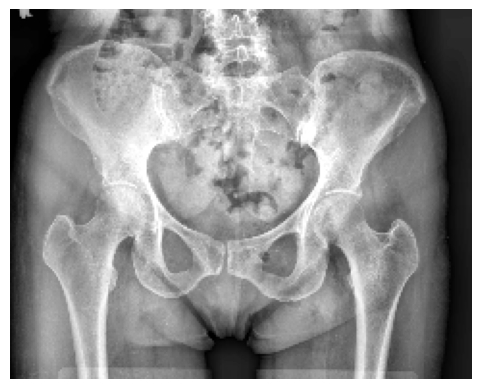

In [23]:
#quick test
testcnt = 1
testchannelcnt = 1
for imgs, ys, aug_scales in train_loader:
    # print(imgs[0].shape)
    # print(ys.shape)
    # print(ys[0])
    # print(aug_scales.shape)
    # print(aug_scales[0])

    for i in range(testchannelcnt):
        plt.imshow(imgs[0][i], cmap = 'gray')
        plt.axis('off')
        plt.show()

    testcnt -= 1
    if testcnt == 0:
        break


# Model

## Model architectures

In [24]:
#simple cnn pipeline
class SimpleCNNModel(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(256 * (img_width // 16) * (img_height // 16), 4096),
            nn.ReLU(),
            # nn.Dropout(0.5),
            nn.Linear(4096, 11)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

In [25]:
#simple cnn + using keypoint detection
class SimpleCNNModelWithKeypointDetection(nn.Module):
    def __init__(self, img_width, img_height, keypoint_detection_model):
        super().__init__()

        self.img_width = img_width
        self.img_height = img_height
        self.keypoint_detection_model = keypoint_detection_model

        self.seq = nn.Sequential(
            nn.Conv2d(11, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(256 * (img_width // 16) * (img_height // 16), 4096),
            nn.ReLU(),
            # nn.Dropout(0.5),
            nn.Linear(4096, 11)
        )

    def forward(self, x):
        heatmaps, _ = self.keypoint_detection_model.encoder(x)
        keypoints = heatmaps_to_keypoints(heatmaps)
        gaussians = keypoints_to_gaussian(keypoints, self.img_height, self.img_width)
        x = torch.cat([x, gaussians], dim = 1)
        x = self.seq(x)
        return x

In [26]:
#alexnet (but bad bc too many parameters)
class AlexNet(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()

        conv_sz = lambda dim, ksz, str, pd : (dim + 2 * pd - ksz) // str + 1
        pool_sz = lambda dim, ksz, str : (dim - ksz) // str + 1

        fin_w = img_width
        fin_h = img_height

        fin_w = pool_sz(conv_sz(fin_w, 11, 4, 2), 3, 2)
        fin_h = pool_sz(conv_sz(fin_h, 11, 4, 2), 3, 2)

        fin_w = pool_sz(conv_sz(fin_w, 5, 1, 2), 3, 2)
        fin_h = pool_sz(conv_sz(fin_h, 5, 1, 2), 3, 2)

        fin_w = conv_sz(fin_w, 3, 1, 1)
        fin_h = conv_sz(fin_h, 3, 1, 1)

        fin_w = conv_sz(fin_w, 3, 1, 1)
        fin_h = conv_sz(fin_h, 3, 1, 1)

        fin_w = pool_sz(conv_sz(fin_w, 3, 1, 1), 3, 2)
        fin_h = pool_sz(conv_sz(fin_h, 3, 1, 1), 3, 2)

        self.seq = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size = 11, stride = 4, padding = 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3, stride = 2),

            nn.Conv2d(96, 256, kernel_size = 5, stride = 1, padding = 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3, stride = 2),

            nn.Conv2d(256, 384, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3, stride = 2),

            nn.Flatten(),
            nn.Dropout(),
            nn.Linear(256 * fin_w * fin_h, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 11)

        )

    def forward(self, x):
        x = self.seq(x)
        return x

In [27]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size = 3, padding = 1)
        )

    def forward(self, x):
        return F.relu(self.block(x) + x)

In [28]:
#resnet-like model
class ResNet(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, padding = 1)
        self.res1 = ResidualBlock(16)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, padding = 1)
        self.res2 = ResidualBlock(32)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
        self.res3 = ResidualBlock(64)
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * (img_width // 8) * (img_height // 8), 128),
            nn.ReLU(),
            # nn.Dropout(0.5), #TODO consider (but haven't tried)
            nn.Linear(128, 11)
        )


    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.res1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.res2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.res3(x)
        x = self.pool3(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

## Coordinate conversion functions

In [29]:
#turn model output into (coordinate, length ab)
def model_to_coord(model_out, DEBUG_MODE = False):
    #units: pixels -> pixels
    #shape: (batch_size, 11)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    eps = 1e-6

    slope = model_out[:, 1] / (model_out[:, 0] + eps)

    all_x_y = [None for _ in range(12)]
    all_x_y[0] = torch.stack([model_out[:, 0], model_out[:, 1]], dim = -1) #D
    all_x_y[1] = torch.stack([model_out[:, 2], slope * model_out[:, 2]], dim = -1) #F
    all_x_y[2] = torch.stack([model_out[:, 3], slope * model_out[:, 3]], dim = -1) #G
    all_x_y[3] = torch.stack([model_out[:, 4], model_out[:, 5]], dim = -1) #H
    all_x_y[4] = torch.stack([model_out[:, 6], model_out[:, 7]], dim = -1) #W
    all_x_y[5] = torch.stack([model_out[:, 8], model_out[:, 7]], dim = -1) #X
    all_x_y[6] = torch.stack([model_out[:, 9], model_out[:, 7]], dim = -1) #Y
    all_x_y[7] = torch.stack([model_out[:, 10], model_out[:, 7]], dim = -1) #Z

    b_x = (model_out[:, 4] / (slope + eps) + model_out[:, 5]) / (slope + 1 / (slope + eps) + eps)
    b_y = slope * b_x
    ab = torch.sqrt(b_x ** 2 + b_y ** 2)

    all_x_y[8] = torch.stack([2 * b_x - model_out[:, 4], 2 * b_y - model_out[:, 5]], dim = -1) #H'
    all_x_y[9] = torch.stack([model_out[:, 1], -model_out[:, 0]], dim = -1) #A'
    all_x_y[10] = torch.stack([-model_out[:, 1], model_out[:, 0]], dim = -1) #A''
    all_x_y[11] = torch.stack([(model_out[:, 6] + model_out[:, 10]) / 2, model_out[:, 7]], dim = -1) #C

    coord = torch.stack(all_x_y, dim = 1)

    ##DEBUG BEGIN##
    if DEBUG_MODE:
        for i in range(model_out.shape[0]):
            plt.scatter(coord[i, :, 0].cpu(), coord[i, :, 1].cpu(), c = 'r')
            plt.scatter(b_x[i].cpu(), b_y[i].cpu())
            for j, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
                curx, cury = coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)
            plt.text(b_x[i].cpu(), b_y[i].cpu(), 'B')
            plt.show()
            print(f'AB: {ab[i].item()}')
            print(coord[i])
            print(b_x[i].item(), b_y[i].item())
    ##DEBUG END##

    return coord, ab

In [30]:
#turn measurements into points
def measurements_to_coord(measurements, ab, pix_per_mm, img_scale_factor, DEBUG_MODE = False):
    #units: mm -> pixels
    #measurements shape: (batch_size, 10)
    #ab shape: (batch_size,)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    measurements = measurements.clone()
    measurements[:, :9] *= pix_per_mm * img_scale_factor

    ang = (270 - measurements[:, 9]) * torch.pi / 180
    cos = torch.cos(ang)
    sin = torch.sin(ang)

    b_x = -cos * ab
    b_y = -sin * ab
    c_x = measurements[:, 4]
    c_y = -measurements[:, 5]

    all_x_y = [None for _ in range(12)]
    all_x_y[0] = torch.stack([cos * measurements[:, 3] / 2, sin * measurements[:, 3] / 2], dim = -1) #D
    all_x_y[2] = torch.stack([all_x_y[0][:, 0] - cos * measurements[:, 8], all_x_y[0][:, 1] - sin * measurements[:, 8]], dim = -1) #G
    all_x_y[1] = torch.stack([all_x_y[2][:, 0] + cos * measurements[:, 7], all_x_y[2][:, 1] + sin * measurements[:, 7]], dim = -1) #F
    all_x_y[3] = torch.stack([b_x + sin * measurements[:, 6] / 2, b_y - cos * measurements[:, 6] / 2], dim = -1) #H
    all_x_y[4] = torch.stack([c_x - measurements[:, 2] / 2, c_y], dim = -1) #W
    all_x_y[7] = torch.stack([c_x + measurements[:, 2] / 2, c_y], dim = -1) #Z
    all_x_y[5] = torch.stack([all_x_y[4][:, 0] + measurements[:, 0], c_y], dim = -1) #X
    all_x_y[6] = torch.stack([all_x_y[7][:, 0] - measurements[:, 1], c_y], dim = -1) #Y

    all_x_y[8] = torch.stack([b_x - sin * measurements[:, 6] / 2, b_y + cos * measurements[:, 6] / 2], dim = -1) #H'
    all_x_y[9] = torch.stack([sin * measurements[:, 3] / 2, -cos * measurements[:, 3] / 2], dim = -1) #A'
    all_x_y[10] = torch.stack([-sin * measurements[:, 3] / 2, cos * measurements[:, 3] / 2], dim = -1) #A''
    all_x_y[11] = torch.stack([c_x, c_y], dim = -1) #C

    coord = torch.stack(all_x_y, dim = 1)

    ##DEBUG BEGIN##
    if DEBUG_MODE:
        for i in range(measurements.shape[0]):
            plt.scatter(coord[i, :, 0].cpu(), coord[i, :, 1].cpu(), c = 'r')
            plt.scatter(b_x[i].cpu(), b_y[i].cpu())
            for j, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
                curx, cury = coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)
            plt.text(b_x[i].cpu(), b_y[i].cpu(), 'B')
            plt.show()
            print(coord[i])
    ##DEBUG END##

    return coord


In [31]:
#turn points into measurements
def coord_to_measurements(coord, pix_per_mm, img_scale_factor):
    #units: pixels -> mm
    #shape (batch_size, 9, 2)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    eps = 1e-6

    slope = coord[:, 0, 1] / (coord[:, 0, 0] + eps)
    b_x = (coord[:, 3, 0] / (slope + eps) + coord[:, 3, 1]) / (slope + 1 / (slope + eps) + eps)
    b_y = slope * b_x

    measurements = [None for _ in range(10)]
    measurements[0] = coord[:, 5, 0] - coord[:, 4, 0]
    measurements[1] = coord[:, 7, 0] - coord[:, 6, 0]
    measurements[2] = coord[:, 7, 0] - coord[:, 4, 0]
    measurements[3] = 2 * torch.norm(coord[:, 0], dim = 1)
    measurements[4] = (coord[:, 4, 0] + coord[:, 7, 0]) / 2
    measurements[5] = -coord[:, 4, 1]
    measurements[6] = 2 * torch.sqrt((coord[:, 3, 0] - b_x) ** 2 + (coord[:, 3, 1] - b_y) ** 2)
    measurements[7] = torch.norm(coord[:, 1] - coord[:, 2], dim = 1)
    measurements[8] = torch.norm(coord[:, 0] - coord[:, 2], dim = 1)
    measurements[9] = torch.arctan(-slope) * 180 / torch.pi + 90

    measurements = torch.stack(measurements, dim = -1).clone()
    measurements[:, :9] /= pix_per_mm * img_scale_factor

    return measurements


## Training

In [32]:
#model
model = SimpleCNNModel(img_width, img_height)
# model = SimpleCNNModelWithKeypointDetection(img_width, img_height, keypoint_detection_model)

#number of epochs
epoch_cnt = 10

#learning rate
learning_rate = 1e-3

#early stopping conditions
best_val_loss = float('inf')
early_stop_lim = 3
early_stop_cnt = 0

In [33]:
#loss function weights
loss_weights = torch.tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]).to(device)

#loss function
lossfn = lambda ypred, yvals, aug_scales : torch.sum(torch.sum(torch.norm(ypred - yvals, dim = 2) * loss_weights, dim = 1) / aug_scales)

#loss history (in sample)
loss_hist = []

In [34]:
#optimizer
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

Epoch: 0

Loss (in sample): 44.309202157767714
Loss (validation): 46.41796659811949

Percent error for each measurement (validation):
0.2479 0.2170 0.1561 0.0586 0.1178 0.0882 0.0737 0.0769 0.0693 0.0313 

===

Epoch: 1

Loss (in sample): 45.396495454630276
Loss (validation): 45.068687438964844

Percent error for each measurement (validation):
0.1775 0.2450 0.1582 0.0520 0.1115 0.0920 0.0643 0.0572 0.0514 0.0343 

===

EARLY STOPPED


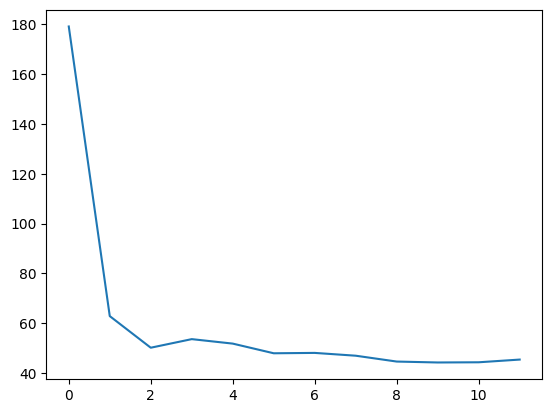

In [36]:
for epoch in range(epoch_cnt):
    model.to(device)
    model.train()

    total_loss = 0

    for images, yvals, aug_scales in train_loader:
        images = images.to(device)
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

        model_out = model(images)
        model_coord, ab = model_to_coord(model_out)
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor)

        loss = lossfn(model_coord, real_coord, aug_scales)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # if epoch % 10 and epoch != epoch_cnt - 1: #only print every x epochs
    #     continue

    print(f'Epoch: {epoch}\n')
    print(f'Loss (in sample): {total_loss / len(train_set)}')

    loss_hist.append(total_loss / len(train_set))

    total_loss = 0
    total_percent_err = torch.zeros(10).to(device)

    model.eval()
    with torch.no_grad():
        for images, yvals, aug_scales in val_loader:
            images = images.to(device)
            yvals = yvals.to(device)
            aug_scales = aug_scales.to(device)

            model_out = model(images)
            model_coord, ab = model_to_coord(model_out)
            real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor)

            loss = lossfn(model_coord, real_coord, aug_scales)

            total_loss += loss.item()

            total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)

        print(f'Loss (validation): {total_loss / len(val_set)}\n')
        print(f'Percent error for each measurement (validation):')
        for i in total_percent_err:
            print(f'{(i.item() / len(val_set)):.4f}', end = ' ')
        print()

        print('\n===\n')

    if total_loss > best_val_loss:
        early_stop_cnt += 1
    else:
        early_stop_cnt = 0
        best_val_loss = total_loss
        torch.save(model.state_dict(), 'best_model.pth')

    if early_stop_cnt >= early_stop_lim:
        print('EARLY STOPPED')
        break

plt.plot(loss_hist)
plt.show()

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

## Testing

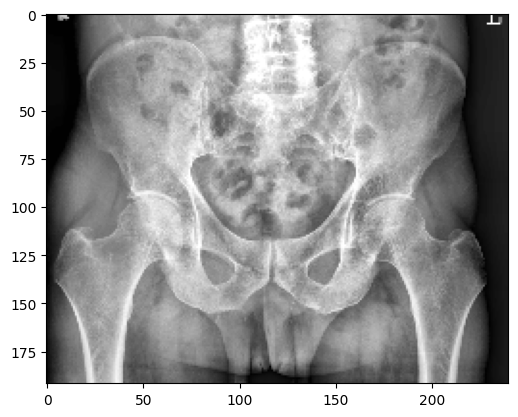

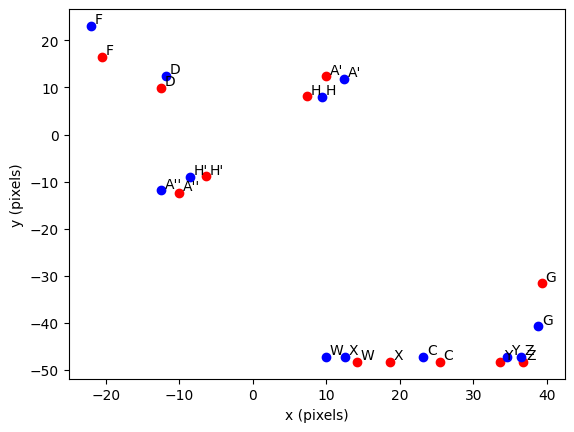

tensor([  7.5484,   5.3558,  38.3911,  54.1972,  43.2689,  82.2307,  37.2323,
        130.5565, 112.8856, 128.8265], device='mps:0')
tensor([  4.2500,   3.0600,  44.8800,  58.4700,  39.4400,  80.4100,  42.0600,
        149.8600, 124.9000, 136.4200], device='mps:0')
tensor(4.4402, device='mps:0')
tensor(2.5000, device='mps:0')


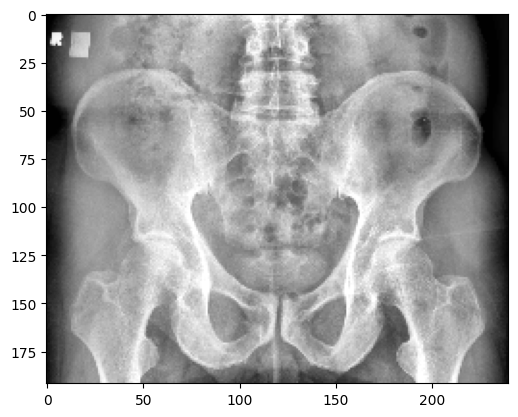

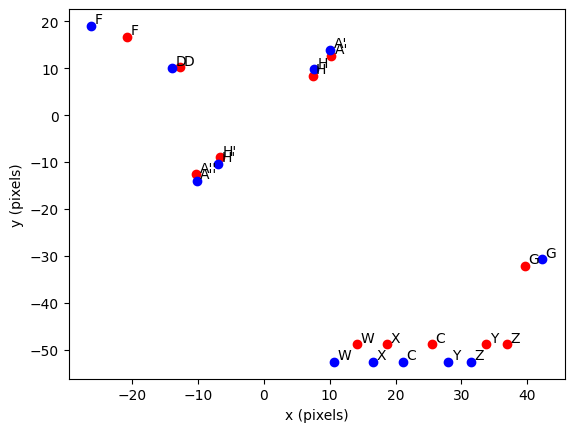

tensor([  7.7328,   5.3428,  38.7307,  55.3168,  43.4132,  83.0873,  38.1573,
        131.8895, 114.2548, 129.0182], device='mps:0')
tensor([ 10.0300,   5.9400,  35.3600,  58.5400,  35.8700,  89.4200,  42.1900,
        143.7500, 117.9900, 126.0100], device='mps:0')
tensor(4.5487, device='mps:0')
tensor(5.9000, device='mps:0')


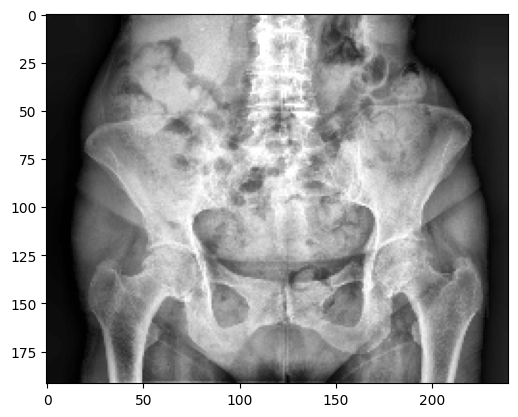

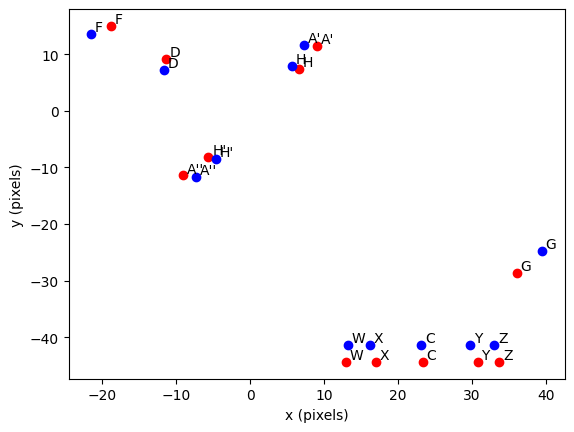

tensor([  6.8616,   4.9340,  35.1737,  49.6103,  39.7078,  75.3625,  33.5846,
        119.2187, 103.1350, 128.5276], device='mps:0')
tensor([  5.1000,   5.6100,  33.6900,  46.5900,  39.3200,  70.3800,  32.8300,
        122.3700, 102.5100, 122.0700], device='mps:0')
tensor(4.0362, device='mps:0')
tensor(3.0000, device='mps:0')


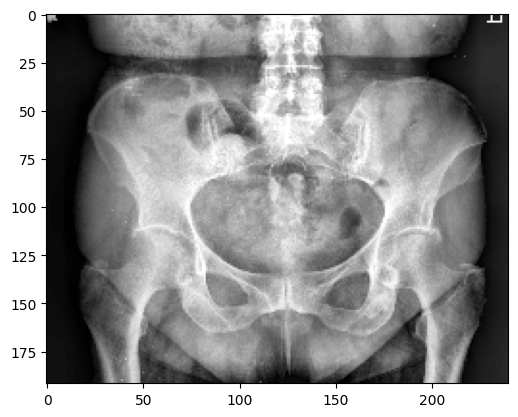

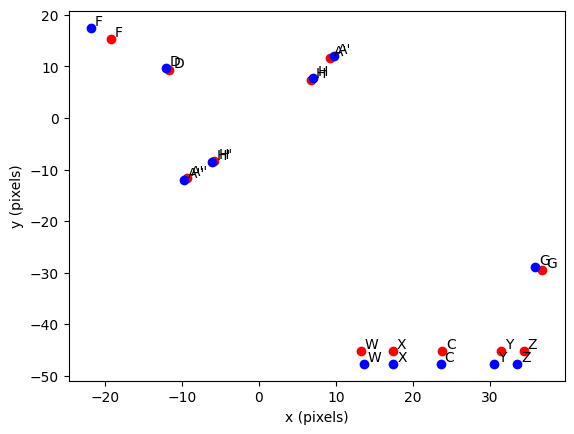

tensor([  7.0132,   5.0343,  35.8782,  50.5059,  40.4554,  76.8549,  34.2898,
        121.7127, 105.2324, 128.6722], device='mps:0')
tensor([  6.4600,   5.1000,  33.8300,  52.7800,  40.1200,  81.0900,  35.5200,
        125.6900, 104.6300, 128.7700], device='mps:0')
tensor(4.1254, device='mps:0')
tensor(3.8000, device='mps:0')


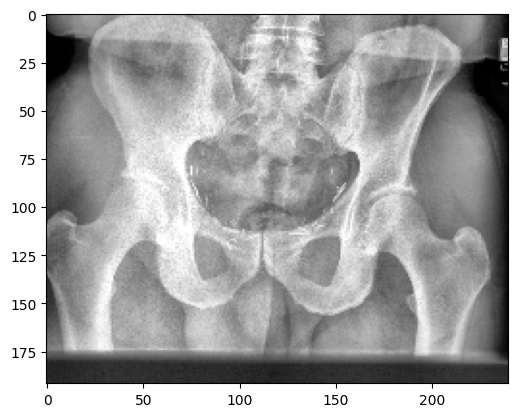

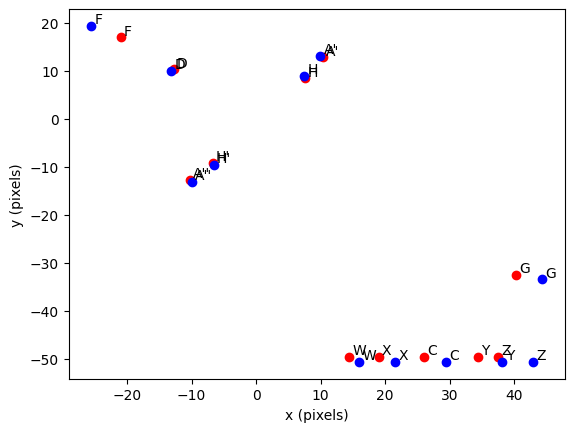

tensor([  7.8160,   5.4609,  39.3622,  55.8059,  44.1576,  84.4334,  38.5156,
        133.7751, 115.8446, 128.9340], device='mps:0')
tensor([  9.5200,   8.1600,  45.9000,  56.1400,  50.1500,  86.1900,  39.6100,
        148.9900, 122.5400, 127.0900], device='mps:0')
tensor(4.5976, device='mps:0')
tensor(5.6000, device='mps:0')


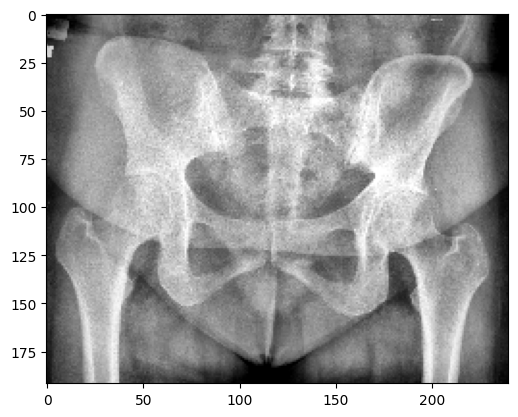

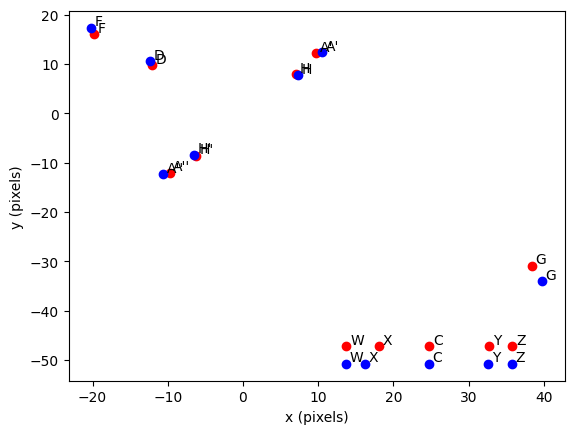

tensor([  7.3545,   5.2535,  37.4734,  52.8735,  42.1179,  80.3574,  36.0165,
        127.0106, 110.2288, 128.8684], device='mps:0')
tensor([  4.4200,   5.2700,  37.5700,  55.2900,  41.9900,  86.3600,  36.1800,
        134.1600, 116.6100, 130.5500], device='mps:0')
tensor(4.3262, device='mps:0')
tensor(2.6000, device='mps:0')


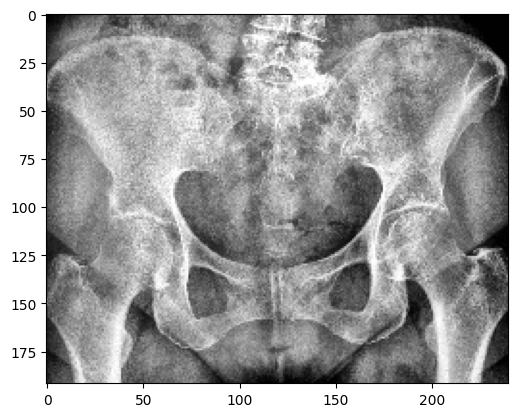

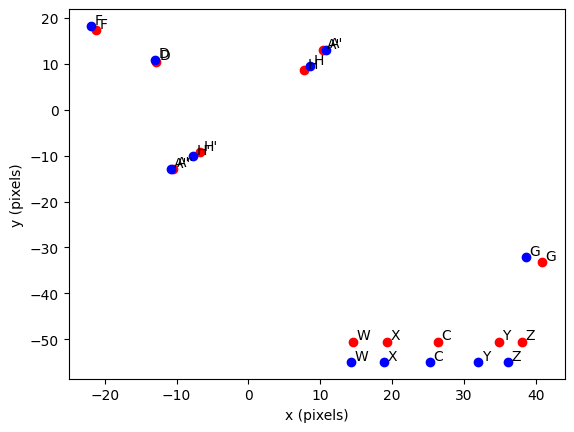

tensor([  7.8937,   5.5538,  39.9431,  56.2419,  44.7938,  85.7637,  39.0348,
        135.9140, 117.6458, 129.0859], device='mps:0')
tensor([  7.8000,   7.0500,  37.0500,  57.5200,  42.9000,  93.3000,  43.3100,
        133.6700, 114.0500, 129.7100], device='mps:0')
tensor(4.6433, device='mps:0')
tensor(4.5882, device='mps:0')


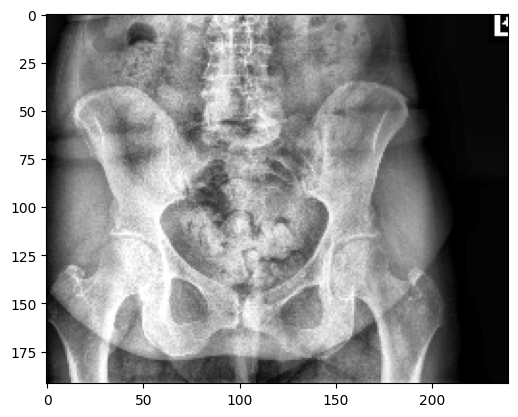

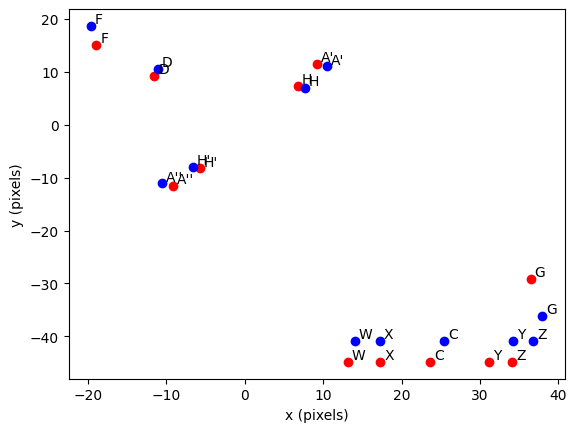

tensor([  6.9868,   5.0259,  35.6343,  50.1100,  40.2282,  76.2627,  34.1112,
        120.5385, 104.4011, 128.5723], device='mps:0')
tensor([  5.4500,   4.4100,  38.7400,  51.9800,  43.1800,  69.4100,  35.1900,
        135.1400, 115.0600, 133.6300], device='mps:0')
tensor(4.1099, device='mps:0')
tensor(3.2059, device='mps:0')


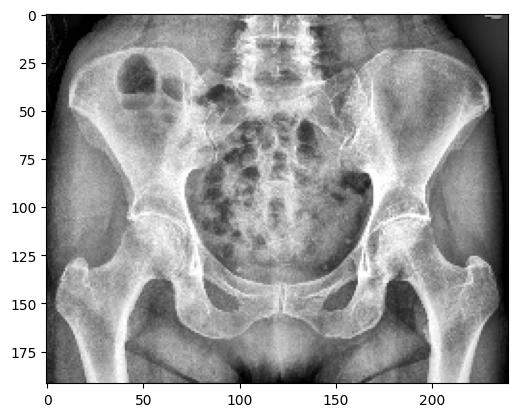

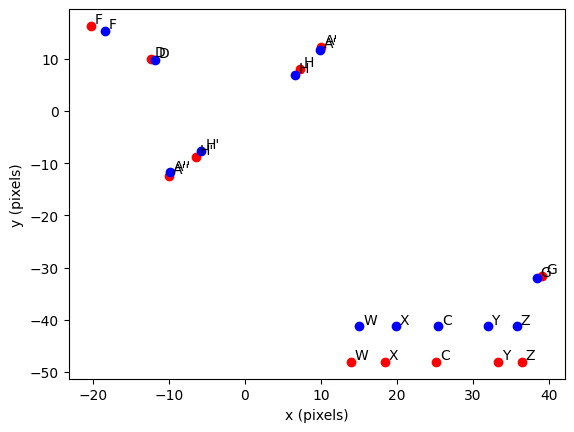

tensor([  7.5219,   5.3214,  38.1536,  54.0697,  42.8284,  81.7743,  36.9362,
        129.5282, 112.4047, 128.9375], device='mps:0')
tensor([  8.1100,   6.5500,  35.1700,  52.1800,  43.2100,  70.2000,  32.4800,
        125.7400, 111.0900, 129.9200], device='mps:0')
tensor(4.4247, device='mps:0')
tensor(4.7706, device='mps:0')


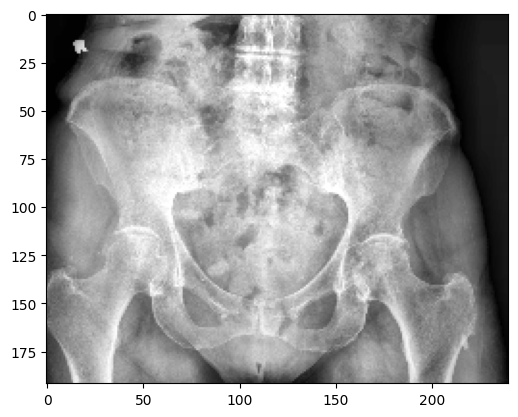

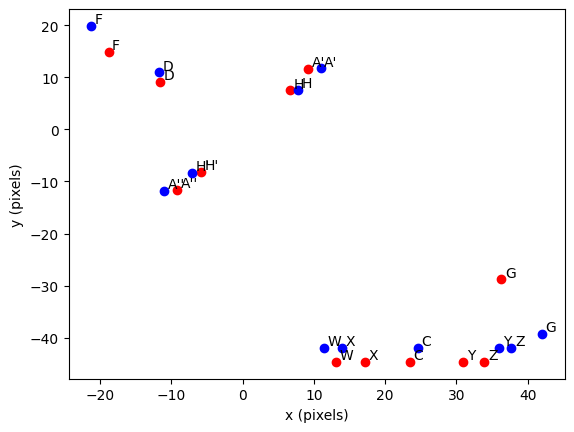

tensor([  6.9452,   4.9818,  35.4595,  50.3362,  39.9569,  75.9107,  34.0266,
        119.5908, 103.9523, 128.4154], device='mps:0')
tensor([  4.2500,   2.9700,  44.6800,  54.6600,  41.8200,  71.4000,  37.0300,
        147.2700, 125.1300, 133.0800], device='mps:0')
tensor(4.0854, device='mps:0')
tensor(2.5000, device='mps:0')
Loss (out sample): 47.23766403198242

Percent error for each measurement (out sample):
0.2751 0.2100 0.0757 0.0577 0.0942 0.1008 0.0777 0.0807 0.0620 0.0259 
tensor([ 1.6448,  1.1715,  3.0301,  3.1173,  4.1038,  8.8730,  2.9562, 11.4221,
         7.3313,  3.3567], device='mps:0')
tensor([1.1455, 1.0522, 2.3285, 2.2500, 3.3526, 7.4817, 2.1239, 8.4030, 5.6624,
        2.8291], device='mps:0')


In [50]:
model.to(device)
model.eval()

total_loss = 0
all_errs = None
total_percent_err = torch.zeros(10).to(device)

with torch.no_grad():
    for images, yvals, aug_scales in test_loader:
        images = images.to(device)
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

        model_out = model(images)
        model_coord, ab = model_to_coord(model_out)
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor)

        loss = lossfn(model_coord, real_coord, aug_scales)

        total_loss += loss.item()
        errs = torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor))
        if all_errs is None:
            all_errs = errs
        else:
            all_errs = torch.cat((all_errs, errs), dim = 0)
        total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)

        plt.imshow(images[0][0].detach().cpu(), cmap = 'gray')
        plt.show()

        plt.scatter(model_coord[0, :, 0].detach().cpu(), model_coord[0, :, 1].detach().cpu(), c = 'r')
        for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
            curx, cury = model_coord[0, i]
            curx = curx.detach().cpu()
            cury = cury.detach().cpu()
            plt.text(curx + 0.5, cury + 0.5, label)
        plt.scatter(real_coord[0, :, 0].detach().cpu(), real_coord[0, :, 1].detach().cpu(), c = 'b')
        for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
            curx, cury = real_coord[0, i]
            curx = curx.detach().cpu()
            cury = cury.detach().cpu()
            plt.text(curx + 0.5, cury + 0.5, label)
        plt.xlabel('x (pixels)')
        plt.ylabel('y (pixels)')
        plt.show()

        print(coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)[0])
        print(yvals[0])

        print(model_coord[0, 5, 0] - model_coord[0, 4, 0])
        print(real_coord[0, 5, 0] - real_coord[0, 4, 0])

    print(f'Loss (out sample): {total_loss / len(test_set)}\n')
    print(f'Percent error for each measurement (out sample):')
    for i in total_percent_err:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
    print()

print(all_errs.mean(dim = 0))
print(all_errs.std(dim = 0, unbiased = True))

# Other stuff

## Saving model

In [ ]:
# torch.save(model.state_dict(), "model_saves/normal_e5_acc16.pth")

### Past models

Format: modeltype_epochcount_worstaccuracy

Normal:
- model_saves/normal_e20_acc19.pth
- model_saves/normal_e18_acc18.pth
- model_saves/normal_e5_acc16.pth (BEST)

Resnet
- model_saves/resnet_e60_acc28.pth (plain)
- model_saves/resnet_e40_acc19.pth (filter)
- model_saves/resnet_e60_acc20.pth (filter, worse than above bc of overfitting)
- model_saves/resnetnoiseaug_e20_acc20.pth (overfitting but learning a lot better)
- model_saves/resnet_noiseaug_dropout_e10_acc18.pth (BEST, still overfit)


## Finding reasonable errors

In [ ]:
reasonable_mm_error = [0.75, 0.75, 1.5, 3, 3, 3, 3, 3, 3, 3] #from meeting
for i in range(1, 11):
    # print(f'{(df[[df.columns[i], df.columns[i + 10]]].stack().mean()):.4f}')
    print(f'{(reasonable_mm_error[i - 1] / df[[df.columns[i], df.columns[i + 10]]].stack().mean()):.4f}')

## Variation in true points

In [ ]:
DBG_data_points = []

for img_file in all_img:
    for img_flip in range(2):
        DBG_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, 0, 1, 1, False))

DBG_set = ImageDataset(DBG_data_points)
DBG_loader = DataLoader(DBG_set, batch_size = 1000, shuffle = False)

model.to(device)
model.eval()

for images, yvals, aug_scales in DBG_loader:
    images = images.to(device)
    yvals = yvals.to(device)
    aug_scales = aug_scales.to(device)

    model_out = model(images)
    model_coord, ab = model_to_coord(model_out)
    model_measurements = coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)
    real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor)

    for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
        plt.scatter((model_coord[:, i, 0] / model_measurements[:, 3]).detach().cpu(), (model_coord[:, i, 1] / model_measurements[:, 3]).detach().cpu())
    plt.xlim(-0.7, 1.1)
    plt.ylim(-1.3, 0.6)
    plt.show()

    for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
        plt.scatter((real_coord[:, i, 0] / yvals[:, 3]).detach().cpu(), (real_coord[:, i, 1] / yvals[:, 3]).detach().cpu())
    plt.xlim(-0.7, 1.1)
    plt.ylim(-1.3, 0.6)
    plt.show()

    for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
        plt.scatter((model_coord[:, i, 0] / model_measurements[:, 3]).detach().cpu(), (model_coord[:, i, 1] / model_measurements[:, 3]).detach().cpu(), c = 'r')
        plt.scatter((real_coord[:, i, 0] / yvals[:, 3]).detach().cpu(), (real_coord[:, i, 1] / yvals[:, 3]).detach().cpu(), c = 'b')
        plt.xlim(-0.7, 1.1)
        plt.ylim(-1.3, 0.6)
        plt.title(label)
        plt.show()

    yvals[:, :9] = yvals[:, :9] / yvals[:, 3].unsqueeze(1)
    model_measurements[:, :9] = model_measurements[:, :9] / model_measurements[:, 3].unsqueeze(1)
    for i in range(10):
        plt.hist(yvals[:, i].detach().cpu(), bins = 30, color = 'b', edgecolor = 'black', alpha = 0.5)
        plt.hist(model_measurements[:, i].detach().cpu(), bins = 30, color = 'r', edgecolor = 'black', alpha = 0.5)
        plt.title(f'Measurement {i + 1}')
        plt.show()



# for images, yvals, aug_scales in DBG_loader:
#     yvals[:, :9] = yvals[:, :9] / yvals[:, 3].unsqueeze(1)

#     print(yvals[0])
#     real_coord = measurements_to_coord(yvals, torch.zeros(images.shape[0]), pix_per_mm, img_scale_factor)
#     print(real_coord[0])
#     for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
#         plt.scatter(real_coord[:, i, 0], real_coord[:, i, 1])
#     plt.show()


# for i, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
#     for images, yvals, aug_scales in DBG_loader:
#         real_coord = measurements_to_coord(yvals, torch.zeros(images.shape[0]), pix_per_mm, img_scale_factor)
#         for j in range(images.shape[0]):
#             plt.scatter(real_coord[j, i, 0], real_coord[j, i, 1])
#     plt.title(label)
#     plt.show()



## Testing individual images

In [ ]:
def model_test(model, device, pix_per_mm, img_scale_factor, imgs, yvals = None, aug_scales = None):
    model.eval()
    model.to(device)

    imgs = imgs.to(device)
    if yvals != None:
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

    model_coord, ab = model_to_coord(model(imgs))
    model_measurements = coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)

    if yvals != None:
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor)
        print(lossfn(model_coord, real_coord, aug_scales))
        print(torch.sum(torch.abs(yvals - model_measurements) / yvals, dim = 0) / yvals.shape[0])

    for i in range(imgs.shape[0]):
        plt.imshow(imgs[i].squeeze().detach().cpu(), cmap = 'gray')
        plt.show()

        plt.scatter(model_coord[i, :, 0].detach().cpu(), model_coord[i, :, 1].detach().cpu(), c = 'r')
        for j, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
            curx, cury = model_coord[i, j]
            plt.text(curx + 0.5, cury + 0.5, label)

        if yvals != None:
            plt.scatter(real_coord[i, :, 0].detach().cpu(), real_coord[i, :, 1].detach().cpu(), c = 'b')
            for j, label in enumerate(['D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'', 'C']):
                curx, cury = real_coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)

        plt.show()

    if yvals != None:
        print(yvals)

    return model_measurements

In [ ]:
curtest = DataPoint(img_dir, test_img[0], False, df, img_width, img_height, 0, 1, 1, False)
curtestimg, curtestyval, curtestaug = curtest.get_image()
model_test(model, device, pix_per_mm, img_scale_factor, curtestimg.unsqueeze(0), curtestyval.unsqueeze(0), curtestaug.unsqueeze(0))

In [ ]:
curtest = DataPoint(img_dir, test_img[0], False, df, img_width, img_height, 0, 1, 0.5, False)
curtestimg, curtestyval, curtestaug = curtest.get_image()
model_test(model, device, pix_per_mm, img_scale_factor, curtestimg.unsqueeze(0), curtestyval.unsqueeze(0), curtestaug.unsqueeze(0))